In [3]:
import numpy as np
import pickle
import argparse
from tqdm import tqdm
import torch

device = 'cpu'
dtype = torch.float32

In [22]:
# Overdamped Langevin step
"""def ULA_update_faster(states_old, target_energy, n_steps, dt=0.01, temperature=1, friction=1, seed=0, sampling_stride=1):
    
    '''states_old = states at last update if I use 40 random walkers it has to be made like that:
    states_old = torch.tensor([[pos_rw_1],[pos_rw_2], ..., [pos_rw_40]]),
    target_energy = target energy function,
    n_steps = # of steps to perform, will define the size of the batch,
    dt = time step'''
    
    states_old = states_old.requires_grad_()
    optimizer = torch.optim.SGD([states_old], lr=dt/friction)
    
    # noisy part of Langevin update
    torch.manual_seed(seed)
    def add_noise(grad):
        noise = np.sqrt(2*friction*temperature/dt) * torch.randn_like(grad)
        return grad + noise
    
    states_old.register_hook(add_noise) # adds something to each gradient computed
    
    states_updates = np.zeros((n_steps//sampling_stride,states_old.shape[0],states_old.shape[1]))#[]
    for t in tqdm(range(n_steps)):
        optimizer.zero_grad()
        loss = target_energy(states_old).sum()
        loss.backward()
        optimizer.step()
        if t % sampling_stride == 0:
            states_updates[t//sampling_stride] = states_old.clone().detach()
        #states_updates.append(states_old.clone().detach())
    return torch.tensor(states_updates)"""


# energy function
def target_energy_python(states):
    gauss1 = 1/np.sqrt(2*np.pi) * torch.exp(-0.5*((states[0])**2 + (states[1])**2))
    energy = -torch.log(gauss1)
    return energy
# vectorization using torch.vmap
target_energy = torch.vmap(target_energy_python, in_dims=0, out_dims=0)

# Overdamped Langevin step
def ULA_update_faster(states_old, target_energy, n_steps, dt=0.01, temperature=1, friction=1, seed=0, sampling_stride=1):
    '''states_old = states at last update if I use 40 random walkers it has to be made like that:
    states_old = torch.tensor([[pos_rw_1],[pos_rw_2], ..., [pos_rw_40]]),
    target_energy = target energy function,
    n_steps = # of steps to perform, will define the size of the batch,
    dt = time step'''
    states_old = states_old.requires_grad_()
    optimizer = torch.optim.SGD([states_old], lr=dt)

    # noisy part of Langevin update
    torch.manual_seed(seed)
    def add_noise(grad):
        noise = np.sqrt(2*temperature/dt) * torch.randn_like(grad)
        return grad*(friction**(-1)) + noise*(friction**(-1/2))
    states_old.register_hook(add_noise) # adds something to each gradient computed

    states_updates = np.zeros((n_steps//sampling_stride,states_old.shape[0],states_old.shape[1]))#[]
    #states_updates = []
    for t in tqdm(range(n_steps)):
        optimizer.zero_grad()
        loss = target_energy(states_old).sum()
        loss.backward()
        optimizer.step()
        if t % sampling_stride == 0:
            states_updates[t//sampling_stride] = states_old.clone().detach()
        #states_updates.append(states_old.clone().detach())
    #states_updates = torch.tensor(states_updates)
    return torch.tensor(states_updates)#torch.stack(states_updates)

In [23]:
# integrate overdamped Langevin equation
states_start = np.column_stack((
        np.random.uniform(-3,3,size=(2,)),
        np.random.uniform(-3,3,size=(2,))
    ))

traj = ULA_update_faster(states_old=torch.tensor(states_start), 
                        target_energy=target_energy, 
                        n_steps=1000, 
                        dt=0.01, 
                        temperature=1, 
                        friction=torch.tensor([1,0.01]),
                        seed=0,
                        sampling_stride=1)

100%|██████████| 1000/1000 [00:01<00:00, 787.65it/s]


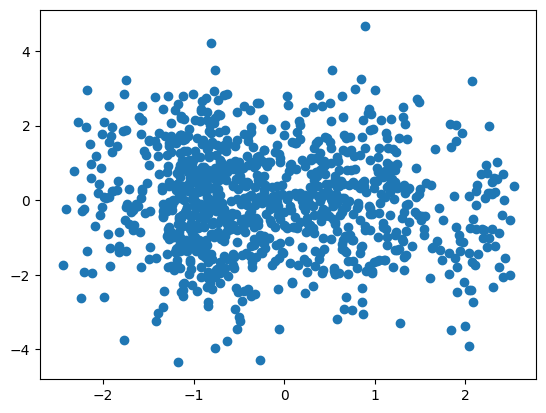

In [24]:
import matplotlib.pyplot as plt
plt.scatter(traj[:,0,0], traj[:,0,1])

In [26]:
traj.shape

torch.Size([1000, 2, 2])

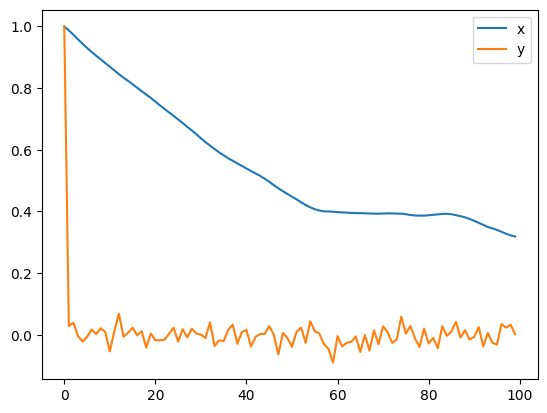

In [29]:
def autocorr2(x): # autocorrelation function
    r2=np.fft.ifft(np.abs(np.fft.fft(x))**2).real
    c=(r2/x.shape-np.mean(x)**2)/np.std(x)**2
    return c[:len(x)//2]

last_lag = 100
lags = np.arange(last_lag)
acf_x = autocorr2(np.array(traj[:,0,0]))[:last_lag]
acf_y = autocorr2(np.array(traj[:,0,1]))[:last_lag]
plt.plot(lags, acf_x, label="x")
plt.plot(lags, acf_y, label="y")
plt.legend()
plt.show()